In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

import pickle

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.nn import MSELoss
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

import optuna

from warnings import filterwarnings
filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)



In [66]:
X = np.load('../artifacts/features.npy')
y = np.load('../artifacts/label.npy')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(objective='reg:absoluteerror', eval_metric='mae', random_state=42),
    'LightGBM': LGBMRegressor(objective='regression_l1', metric='mae', random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(loss_function='MAE', eval_metric='MAE', random_seed=42, verbose=0)
}

In [70]:
def cross_validation(model, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mae_l, rmse_l, r2_l = [], [], []

    for FOLD, (train_index, val_index) in enumerate(kf.split(X)):
        print(f"FOLD: {FOLD+1}")
        X_train_cv, X_val_cv = X[train_index], X[val_index]
        y_train_cv, y_val_cv = y[train_index], y[val_index]

        y_train_cv_log = np.log1p(y_train_cv)

        model.fit(X_train_cv, y_train_cv_log)
        y_pred_cv = model.predict(X_val_cv)

        y_pred_cv = np.expm1(y_pred_cv)

        mae = mean_absolute_error(y_val_cv, y_pred_cv)
        rmse = np.sqrt(mean_squared_error(y_val_cv, y_pred_cv))
        r2 = r2_score(y_val_cv, y_pred_cv)

        mae_l.append(mae)
        rmse_l.append(rmse)
        r2_l.append(r2)
        print(f"MAE: {mae:.4f}\nRMSE: {rmse:.4f}\nR2: {r2:.4f}")

    print(f"Cross-Validation Results for {model.__class__.__name__}:")
    print(f"Average MAE: {np.mean(mae_l):.4f}")
    print(f"Average RMSE: {np.mean(rmse_l):.4f}")
    print(f"Average R2 Score: {np.mean(r2_l):.4f}")

    return np.mean(mae_l), np.mean(rmse_l), np.mean(r2_l)

In [71]:
def modeling(models, X, y):
    results = {}
    mae_l, rmse_l, r2_l = [], [], []
    for name, model in models.items():
        print(f"Model: {name}")
        mae, rmse, r2 = cross_validation(model, X, y, n_splits=5)
        mae_l.append(mae)
        rmse_l.append(rmse)
        r2_l.append(r2)

        print("-" * 30)
    
    results_df = pd.DataFrame({
        'Model': list(models.keys()),
        'MAE_CV': mae_l,
        'RMSE_CV': rmse_l,
        'R2_CV': r2_l
    }).sort_values(by='MAE_CV')
   
    return results_df

results_df = modeling(models, X, y)
print(results_df)




Model: Linear Regression
FOLD: 1
MAE: 2980217638.3802
RMSE: 5207013409.8984
R2: 0.3112
FOLD: 2
MAE: 2980933031.4895
RMSE: 5733374475.4757
R2: 0.2472
FOLD: 3
MAE: 4801606334.4094
RMSE: 22093217354.8867
R2: -8.7791
FOLD: 4
MAE: 4972753209.4557
RMSE: 16670546244.3831
R2: -2.1304
FOLD: 5
MAE: 8952615874.7673
RMSE: 41573563064.2513
R2: -36.2844
Cross-Validation Results for LinearRegression:
Average MAE: 4937625217.7004
Average RMSE: 18255542909.7791
Average R2 Score: -9.3271
------------------------------
Model: Decision Tree
FOLD: 1
MAE: 1627341585.4295
RMSE: 2942384548.4648
R2: 0.7801
FOLD: 2
MAE: 1931046754.7277
RMSE: 4053189925.8827
R2: 0.6238
FOLD: 3
MAE: 2297408145.9084
RMSE: 4491583811.1797
R2: 0.5958
FOLD: 4
MAE: 2588946931.6219
RMSE: 6122189470.8962
R2: 0.5778
FOLD: 5
MAE: 2241721395.3648
RMSE: 4839414451.1243
R2: 0.4948
Cross-Validation Results for DecisionTreeRegressor:
Average MAE: 2137292962.6105
Average RMSE: 4489752441.5095
Average R2 Score: 0.6144
---------------------------

In [11]:
# Voting Ensemble wit top 3 models

top_models = results_df.nsmallest(3, 'MAE_CV')['Model'].tolist()
voting_estimators = [(name, models[name]) for name in top_models]
voting_regressor = VotingRegressor(estimators=voting_estimators)
y_train_log = np.log1p(y_train)
voting_regressor.fit(X_train, y_train_log)
y_pred_voting = voting_regressor.predict(X_test)
y_pred_voting = np.expm1(y_pred_voting)
mae_voting = mean_absolute_error(y_test, y_pred_voting)
rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))
r2_voting = r2_score(y_test, y_pred_voting)
print(f"Voting Regressor MAE: {mae_voting:.4f}")
print(f"Voting Regressor RMSE: {rmse_voting:.4f}")
print(f"Voting Regressor R2: {r2_voting:.4f}")

Voting Regressor MAE: 1297519369.4663
Voting Regressor RMSE: 2292118700.8210
Voting Regressor R2: 0.8665


In [12]:
cross_validation(voting_regressor, X, y, n_splits=5)

FOLD: 1
MAE: 1308653592.4258
RMSE: 2272869365.0428
R2: 0.8688
FOLD: 2
MAE: 1557527342.0570
RMSE: 2814511996.9432
R2: 0.8186
FOLD: 3
MAE: 1712960100.0870
RMSE: 3494177245.7531
R2: 0.7554
FOLD: 4
MAE: 2232129165.4706
RMSE: 5721292725.3495
R2: 0.6313
FOLD: 5
MAE: 1581545385.9650
RMSE: 2886979952.2598
R2: 0.8202
Cross-Validation Results for VotingRegressor:
Average MAE: 1678563117.2011
Average RMSE: 3437966257.0697
Average R2 Score: 0.7788


(np.float64(1678563117.2010689),
 np.float64(3437966257.069673),
 np.float64(0.7788481337688544))

In [13]:
def optimize_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000,10),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }

    rf = RandomForestRegressor(**params, random_state=42)
    y_train_log = np.log1p(y_train)
    rf.fit(X_train, y_train_log)
    y_pred = rf.predict(X_test)
    y_pred = np.expm1(y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    return mae
study = optuna.create_study(direction='minimize')
study.optimize(optimize_rf, n_trials=20)
best_params = study.best_params
print("Best Hyperparameters for Random Forest:", best_params)

[I 2025-12-21 07:57:04,392] A new study created in memory with name: no-name-459ea5af-6a07-4e60-8214-91beafe7a526
[I 2025-12-21 07:57:41,655] Trial 0 finished with value: 1293479057.5441759 and parameters: {'n_estimators': 1530, 'max_depth': 31, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 0 with value: 1293479057.5441759.
[I 2025-12-21 07:58:50,367] Trial 1 finished with value: 1394394425.3279788 and parameters: {'n_estimators': 1770, 'max_depth': 43, 'min_samples_split': 2, 'min_samples_leaf': 8}. Best is trial 0 with value: 1293479057.5441759.
[I 2025-12-21 07:59:39,924] Trial 2 finished with value: 1284168514.5617373 and parameters: {'n_estimators': 1730, 'max_depth': 33, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 2 with value: 1284168514.5617373.
[I 2025-12-21 07:59:55,732] Trial 3 finished with value: 1371848339.8786 and parameters: {'n_estimators': 940, 'max_depth': 33, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 2 with value

Best Hyperparameters for Random Forest: {'n_estimators': 1730, 'max_depth': 33, 'min_samples_split': 8, 'min_samples_leaf': 1}


In [14]:
def optimize_xgboost(trial):
    params ={
        'objective': 'reg:absoluteerror',
        'eval_metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000,10),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
    }

    xgb = XGBRegressor(**params, random_state=42)
    y_train_log = np.log1p(y_train)
    xgb.fit(X_train, y_train_log)
    y_pred = xgb.predict(X_test)
    y_pred = np.expm1(y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    return mae
study = optuna.create_study(direction='minimize')
study.optimize(optimize_xgboost, n_trials=20)
best_params_xgb = study.best_params
print("Best Hyperparameters for XGBoost:", best_params_xgb)

[I 2025-12-21 08:04:17,299] A new study created in memory with name: no-name-a002bded-6c83-4b5d-b0ba-21cd09ec940c


[I 2025-12-21 08:05:01,793] Trial 0 finished with value: 1430324608.0 and parameters: {'n_estimators': 1860, 'max_depth': 15, 'learning_rate': 0.1415867412261559, 'subsample': 0.6280175331436318, 'reg_alpha': 0.7003002011585645, 'reg_lambda': 0.36088958162080365}. Best is trial 0 with value: 1430324608.0.
[I 2025-12-21 08:05:13,487] Trial 1 finished with value: 1436138368.0 and parameters: {'n_estimators': 400, 'max_depth': 17, 'learning_rate': 0.16101466789057023, 'subsample': 0.7217921656887945, 'reg_alpha': 0.9577579314002551, 'reg_lambda': 0.2362930929245416}. Best is trial 0 with value: 1430324608.0.
[I 2025-12-21 08:05:29,295] Trial 2 finished with value: 1511614592.0 and parameters: {'n_estimators': 770, 'max_depth': 13, 'learning_rate': 0.20174426800364145, 'subsample': 0.7465122830516826, 'reg_alpha': 0.3790128595531236, 'reg_lambda': 0.09628355616248185}. Best is trial 0 with value: 1430324608.0.
[I 2025-12-21 08:05:38,598] Trial 3 finished with value: 1340524416.0 and parame

Best Hyperparameters for XGBoost: {'n_estimators': 480, 'max_depth': 11, 'learning_rate': 0.03314460485547553, 'subsample': 0.7894080871125287, 'reg_alpha': 0.35688097399245666, 'reg_lambda': 0.7991972746484678}


In [15]:
# add objective and eval_metric in best_params_xgb
best_params_xgb['objective'] = 'reg:absoluteerror'
best_params_xgb['eval_metric'] = 'mae'

In [16]:
def optimize_cat(trial):
    params = {
        'loss_function': 'MAE',
        'eval_metric': 'MAE',
        'iterations': trial.suggest_int('iterations', 100, 2000,10),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
    }
    cat = CatBoostRegressor(**params, random_state=42, verbose=0)
    y_train_log = np.log1p(y_train)
    cat.fit(X_train, y_train_log)
    y_pred = cat.predict(X_test)
    y_pred = np.expm1(y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    return mae
study = optuna.create_study(direction='minimize')
study.optimize(optimize_cat, n_trials=20)
best_params_cat = study.best_params
print("Best Hyperparameters for CatBoost:", best_params_cat)

[I 2025-12-21 08:10:07,881] A new study created in memory with name: no-name-37f1ea90-3158-4958-bf2e-d9930842f87b
[I 2025-12-21 08:10:37,847] Trial 0 finished with value: 1366738312.012025 and parameters: {'iterations': 1880, 'depth': 8, 'learning_rate': 0.03879603264364917, 'l2_leaf_reg': 2.6976129923124113}. Best is trial 0 with value: 1366738312.012025.
[I 2025-12-21 08:10:39,862] Trial 1 finished with value: 1521900977.2433574 and parameters: {'iterations': 390, 'depth': 4, 'learning_rate': 0.014565740126841762, 'l2_leaf_reg': 6.144773904112711}. Best is trial 0 with value: 1366738312.012025.
[I 2025-12-21 08:11:27,539] Trial 2 finished with value: 1475575417.6723573 and parameters: {'iterations': 1830, 'depth': 9, 'learning_rate': 0.28201265464277114, 'l2_leaf_reg': 2.025876043274424}. Best is trial 0 with value: 1366738312.012025.
[I 2025-12-21 08:11:33,790] Trial 3 finished with value: 1426947368.5673556 and parameters: {'iterations': 1390, 'depth': 4, 'learning_rate': 0.0183244

Best Hyperparameters for CatBoost: {'iterations': 1740, 'depth': 7, 'learning_rate': 0.03996680315990049, 'l2_leaf_reg': 5.000949132159333}


In [18]:
best_params_cat['loss_function'] = 'MAE'
best_params_cat['eval_metric'] = 'MAE'

In [72]:
estimators = [
    ('Random Forest', RandomForestRegressor(**best_params, random_state=42)),
    ('XGBoost', XGBRegressor(**best_params_xgb, random_state=42)),
    ('CatBoost', CatBoostRegressor(**best_params_cat, random_state=42, verbose=0))
]

# single pred

voting_regressor = VotingRegressor(estimators=estimators)
voting_regressor.fit(X_train, np.log1p(y_train))
y_pred_voting = voting_regressor.predict(X_test)
y_pred_voting = np.expm1(y_pred_voting)
mae_voting = mean_absolute_error(y_test, y_pred_voting)
rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))
r2_voting = r2_score(y_test, y_pred_voting)
print(f"Voting Regressor MAE: {mae_voting:.4f}")
print(f"Voting Regressor RMSE: {rmse_voting:.4f}")
print(f"Voting Regressor R2: {r2_voting:.4f}")


cross_validation(voting_regressor, X, y, n_splits=5)

Voting Regressor MAE: 1272059435.1361
Voting Regressor RMSE: 2259897984.1524
Voting Regressor R2: 0.8703
FOLD: 1
MAE: 1276947489.5534
RMSE: 2302213840.0379
R2: 0.8654
FOLD: 2
MAE: 1553647395.7314
RMSE: 2821327315.8953
R2: 0.8177
FOLD: 3
MAE: 1672512834.6980
RMSE: 3351906686.4984
R2: 0.7749
FOLD: 4
MAE: 2238680174.1701
RMSE: 5767128524.8359
R2: 0.6254
FOLD: 5
MAE: 1569684240.8836
RMSE: 2826585599.4113
R2: 0.8276
Cross-Validation Results for VotingRegressor:
Average MAE: 1662294427.0073
Average RMSE: 3413832393.3358
Average R2 Score: 0.7822


(np.float64(1662294427.0072944),
 np.float64(3413832393.335772),
 np.float64(0.7821952835745869))

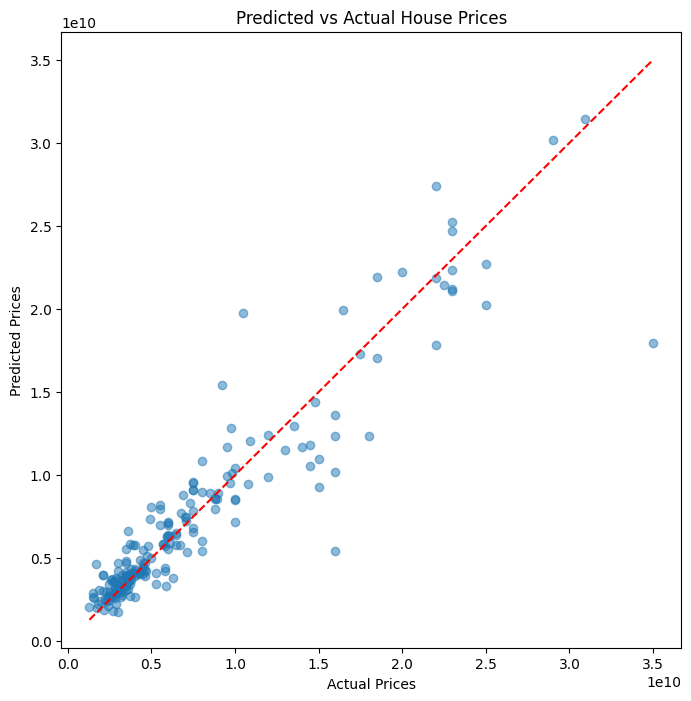

In [ ]:
def plot_pred_actual(y_true, y_pred):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title('Predicted vs Actual House Prices')
    plt.show()

plot_pred_actual(y_test, y_pred_voting)

In [21]:
voting_regressor.fit(X, np.log1p(y))
with open('../artifacts/voting_regressor.pkl', 'wb') as f:
    pickle.dump(voting_regressor, f)

## Deep Learning Model

In [61]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, torch.log1p(y_train))
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [64]:
class ANNModel(nn.Module):
    def __init__(self, input_dim):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.dropout(x)
        x = self.fc5(x)

        return x
    
input_dim = X.shape[1]
model = ANNModel(input_dim)

In [65]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for inputs, targets in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate_model(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    all_target, all_pred = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            
            outputs = torch.expm1(outputs) 
            
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            all_target.append(targets.detach().cpu().numpy())
            all_pred.append(outputs.detach().cpu().numpy())
            
    epoch_loss = running_loss / len(dataloader.dataset)
    all_target = np.vstack(all_target)
    all_pred = np.vstack(all_pred)
    
    mae = mean_absolute_error(all_target, all_pred)
    rmse = np.sqrt(mean_squared_error(all_target, all_pred))
    r2 = r2_score(all_target, all_pred)
    return mae, rmse, r2, epoch_loss

criterion = MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
num_epochs = 100

patience = 30                
patience_counter = 0         
best_mae = float('inf')      
best_model_path = 'best_model.pth'

print("Start Training...")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    
    mae, rmse, r2, val_loss = evaluate_model(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

    scheduler.step(val_loss)

    if mae < best_mae:
        print(f"MAE improved from {best_mae:.4f} to {mae:.4f}. Saving model...")
        best_mae = mae             
        patience_counter = 0        
        torch.save(model.state_dict(), best_model_path) 
    else:
        patience_counter += 1       

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        print(f"Best MAE: {best_mae:.4f}")
        break

print("Training Completed.")

model.load_state_dict(torch.load(best_model_path))
print("Loaded Best Model State.")

Start Training...
Epoch [1/100] | Train Loss: 198.4234 | Val Loss: 71814463717157664934854656.0000 | MAE: 1162620829696.0000 | RMSE: 8474341079261.8213 | R2: -1824405.2500
MAE improved from inf to 1162620829696.0000. Saving model...
Epoch [2/100] | Train Loss: 26.6144 | Val Loss: 621152287130413325877248.0000 | MAE: 155160264704.0000 | RMSE: 788132167391.7561 | R2: -15779.0283
MAE improved from 1162620829696.0000 to 155160264704.0000. Saving model...
Epoch [3/100] | Train Loss: 22.8721 | Val Loss: 430533576961717960704000.0000 | MAE: 54448189440.0000 | RMSE: 656150540585.2347 | R2: -10936.4648
MAE improved from 155160264704.0000 to 54448189440.0000. Saving model...
Epoch [4/100] | Train Loss: 18.8120 | Val Loss: 8550523795016100347904.0000 | MAE: 13979801600.0000 | RMSE: 92469044114.3763 | R2: -216.2213
MAE improved from 54448189440.0000 to 13979801600.0000. Saving model...
Epoch [5/100] | Train Loss: 16.8449 | Val Loss: 48088762998604768632373248.0000 | MAE: 736886915072.0000 | RMSE: 